# Importing the Packages
# Checking for the Packages Installations

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
import os # Import the os module
warnings.filterwarnings('ignore')

## THE DATA LOADING AND PREPROCESSING

In [21]:
class FloodDataProcessor:
    """Process and analyze flood risk dataset"""

    def __init__(self, csv_path):
        """Initialize data processor with CSV file"""
        # Removed the hardcoded csv_path, now it uses the one passed as argument
        self.df = pd.read_csv(csv_path)
        self.process_data()

    def process_data(self):
        """Process raw data for analysis"""
        print("=" * 80)
        print("FLOOD RISK DATA LOADING AND ANALYSIS")
        print("=" * 80)

        print(f"\nDataset Shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")

        # Filter out invalid latitude/longitude values
        # Assuming valid latitudes for India are roughly between 5 and 40 degrees North.
        # Longitudes for India are roughly between 68 and 98 degrees East.
        initial_rows = len(self.df)
        self.df = self.df[(self.df['Latitude'] >= 5) & (self.df['Latitude'] <= 40)]
        self.df = self.df[(self.df['Longitude'] >= 68) & (self.df['Longitude'] <= 98)]
        filtered_rows = len(self.df)
        if initial_rows != filtered_rows:
            print(f"\nRemoved {initial_rows - filtered_rows} rows with invalid Latitude/Longitude.")
            print(f"New Dataset Shape: {self.df.shape}")

        # Display basic statistics
        print("\nDataset Summary:")
        print(self.df.describe())

        print("\nMissing Values:")
        print(self.df.isnull().sum())

        # Flood statistics
        flood_count = (self.df['Flood Occurred'] == 1).sum()
        print(f"\n✓ Flooded Areas: {flood_count} ({flood_count/len(self.df)*100:.2f}%%)")
        print(f"✓ Non-Flooded Areas: {len(self.df)-flood_count}")

        # Calculate flood risk score
        self.calculate_risk_score()

    def calculate_risk_score(self):
        """Calculate composite flood risk score (0-1)"""
        scaler = MinMaxScaler(feature_range=(0, 1))

        # Features that increase flood risk
        risk_features = self.df[[
            'Rainfall (mm)',
            'River Discharge (m³/s)',
            'Water Level (m)',
            'Population Density'
        ]].copy()

        # Features that decrease flood risk
        safety_features = self.df[[
            'Elevation (m)',
            'Infrastructure'
        ]].copy()

        # Normalize risk features
        risk_normalized = scaler.fit_transform(risk_features)

        # Normalize safety features and invert
        safety_normalized = 1 - scaler.fit_transform(safety_features.fillna(0))

        # Composite risk score
        weights = [0.3, 0.25, 0.25, 0.2]  # Rainfall, Discharge, Water Level, Pop Density
        self.df['Flood_Risk_Score'] = (
            risk_normalized[:, 0] * weights[0] +
            risk_normalized[:, 1] * weights[1] +
            risk_normalized[:, 2] * weights[2] +
            risk_normalized[:, 3] * weights[3]
        )

        # Adjust for safety features
        self.df['Flood_Risk_Score'] = (
            self.df['Flood_Risk_Score'] * 0.7 +
            (safety_normalized[:, 0] + safety_normalized[:, 1]) / 2 * 0.3
        )

        self.df['Risk_Category'] = pd.cut(
            self.df['Flood_Risk_Score'],
            bins=[0, 0.33, 0.66, 1.0],
            labels=['Low', 'Medium', 'High']
        )

        print("\nFlood Risk Score Distribution:")
        print(self.df['Risk_Category'].value_counts())


## SAPITIAL NETWORK CONSTRUCTION

In [22]:
class SpatialNetwork:
    """Build spatial network from geographic coordinates"""

    def __init__(self, df, grid_size=10):
        """
        Create spatial network from latitude/longitude coordinates

        Args:
            df: DataFrame with Latitude and Longitude columns
            grid_size: Number of grid cells per dimension
        """
        self.df = df
        self.grid_size = grid_size
        self.create_grid()
        self.build_network()

    def create_grid(self):
        """Create grid cells from geographic data"""
        # Get bounds
        lat_min, lat_max = self.df['Latitude'].min(), self.df['Latitude'].max()
        lon_min, lon_max = self.df['Longitude'].min(), self.df['Longitude'].max()

        # Create grid
        self.lat_edges = np.linspace(lat_min, lat_max, self.grid_size + 1)
        self.lon_edges = np.linspace(lon_min, lon_max, self.grid_size + 1)

        # Assign grid cells to each location
        self.df['Lat_Grid'] = pd.cut(self.df['Latitude'], bins=self.lat_edges, labels=False, include_lowest=True)
        self.df['Lon_Grid'] = pd.cut(self.df['Longitude'], bins=self.lon_edges, labels=False, include_lowest=True)

        print(f"\n✓ Spatial Grid Created: {self.grid_size}x{self.grid_size}")

    def build_network(self):
        """Build network representation"""
        # Create nodes: grid cell centers
        self.nodes = {}
        node_id = 0

        for i in range(self.grid_size):
            for j in range(self.grid_size):
                center_lat = (self.lat_edges[i] + self.lat_edges[i+1]) / 2
                center_lon = (self.lon_edges[j] + self.lon_edges[j+1]) / 2

                # Get average risk for this cell
                cell_data = self.df[
                    (self.df['Lat_Grid'] == i) &
                    (self.df['Lon_Grid'] == j)
                ]

                if len(cell_data) > 0:
                    avg_risk = cell_data['Flood_Risk_Score'].mean()
                    avg_elevation = cell_data['Elevation (m)'].mean()
                    population = cell_data['Population Density'].mean()
                else:
                    # Assign default/interpolated values for empty cells
                    avg_risk = 0.5 # Neutral risk
                    avg_elevation = 100 # Low elevation
                    population = 100 # Low population

                self.nodes[node_id] = {
                    'grid_pos': (i, j),
                    'lat': center_lat,
                    'lon': center_lon,
                    'risk_score': avg_risk,
                    'elevation': avg_elevation,
                    'population': population,
                    'count': len(cell_data)
                }
                node_id += 1

        # Create edges: connections between adjacent cells
        self.edges = {}
        edge_id = 0

        for node_id, node_info in self.nodes.items():
            i, j = node_info['grid_pos']

            # Connect to adjacent cells (up, down, left, right, diagonals)
            neighbors = [
                (i-1, j), (i+1, j), (i, j-1), (i, j+1),
                (i-1, j-1), (i-1, j+1), (i+1, j-1), (i+1, j+1)
            ]

            for ni, nj in neighbors:
                if 0 <= ni < self.grid_size and 0 <= nj < self.grid_size:
                    neighbor_id = ni * self.grid_size + nj

                    # Calculate edge weight (travel time)
                    dist = np.sqrt((i - ni)**2 + (j - nj)**2)
                    risk_penalty = (self.nodes[node_id]['risk_score'] +
                                  self.nodes[neighbor_id]['risk_score']) / 2

                    travel_time = dist * (1 + risk_penalty * 3)

                    self.edges[edge_id] = {
                        'from': node_id,
                        'to': neighbor_id,
                        'distance': dist,
                        'risk': risk_penalty,
                        'travel_time': travel_time,
                        'capacity': 100  # evacuation capacity
                    }
                    edge_id += 1

        print(f"✓ Network Built: {len(self.nodes)} nodes, {len(self.edges)} edges")


## ADVANCE PSO MODEL

In [23]:
class PSO_EvacuationOptimizer:
    """Particle Swarm Optimization for evacuation route planning"""

    def __init__(self, network, safe_zones=5, population_to_evacuate=10000):
        """
        Initialize PSO optimizer

        Args:
            network: SpatialNetwork object
            safe_zones: Number of safe zones to identify
            population_to_evacuate: Total people to evacuate
        """
        self.network = network
        self.safe_zones = safe_zones
        self.population = population_to_evacuate
        self.identify_safe_zones()
        self.initialize_swarm()

    def identify_safe_zones(self):
        """Identify safe zones (low-risk, high-elevation areas)"""
        # Create node feature matrix
        node_features = []
        node_ids = []

        for node_id, node_info in self.network.nodes.items():
            # Safety score: high elevation + low risk
            # Ensure elevation is not zero before normalization to avoid division by zero or strange behavior
            max_elevation = self.network.df['Elevation (m)'].max()
            normalized_elevation = node_info['elevation'] / max_elevation if max_elevation > 0 else 0

            safety_score = (
                normalized_elevation -  # normalize by max elevation
                node_info['risk_score']
            )
            node_features.append(safety_score)
            node_ids.append(node_id)

        node_features = np.array(node_features).reshape(-1, 1)

        # Find safest nodes as zones
        kmeans = KMeans(n_clusters=self.safe_zones, random_state=42, n_init=10) # Added n_init to suppress warning
        kmeans.fit(node_features)

        self.safe_zone_ids = []
        for i in range(self.safe_zones):
            cluster_nodes = np.where(kmeans.labels_ == i)[0]
            if len(cluster_nodes) > 0: # Ensure cluster is not empty
                safest_idx = cluster_nodes[np.argmax(node_features[cluster_nodes])]
                self.safe_zone_ids.append(node_ids[safest_idx])
            else:
                # If a cluster is empty, pick a random node as a safe zone (fallback)
                self.safe_zone_ids.append(np.random.choice(node_ids))

        print(f"\n✓ Safe Zones Identified: {self.safe_zones} zones")

    def initialize_swarm(self, swarm_size=40):
        """Initialize particle swarm"""
        self.swarm_size = swarm_size
        self.particles = []
        self.velocities = []
        self.pbest_positions = []
        self.pbest_fitness = []

        # Random initialization
        for _ in range(swarm_size):
            # Route: sequence of nodes leading to a safe zone
            route_length = 8
            route = [np.random.randint(0, len(self.network.nodes))
                    for _ in range(route_length)]
            route.append(np.random.choice(self.safe_zone_ids))

            position = np.array(route, dtype=float)
            velocity = np.random.uniform(-1, 1, len(position))

            self.particles.append(position)
            self.velocities.append(velocity)
            self.pbest_positions.append(position.copy())

            # Calculate fitness
            fitness = self.evaluate_fitness(position)
            self.pbest_fitness.append(fitness)

        # Global best
        best_idx = np.argmax(self.pbest_fitness)
        self.gbest_position = self.pbest_positions[best_idx].copy()
        self.gbest_fitness = self.pbest_fitness[best_idx]

        print(f"✓ Swarm Initialized: {swarm_size} particles")

    def evaluate_fitness(self, route):
        """
        Evaluate route fitness

        Fitness components:
        - Minimize travel time
        - Minimize risk exposure
        - Maximize elevation gain (safety)
        """
        route = [int(n) % len(self.network.nodes) for n in route]

        total_time = 0
        total_risk = 0
        elevation_gain = 0

        for i in range(len(route) - 1):
            node_from = route[i]
            node_to = route[i + 1]

            # Find edge
            edge_found = False
            for edge in self.network.edges.values():
                # Check both directions for the edge
                if (edge['from'] == node_from and edge['to'] == node_to) or \
                   (edge['from'] == node_to and edge['to'] == node_from):
                    total_time += edge['travel_time']
                    total_risk += edge['risk'] * 10
                    edge_found = True
                    break

            if not edge_found:
                total_time += 10  # penalty
                total_risk += 5

            # Elevation gain
            if node_from in self.network.nodes and node_to in self.network.nodes:
                elev_from = self.network.nodes[node_from]['elevation']
                elev_to = self.network.nodes[node_to]['elevation']
                elevation_gain += max(0, elev_to - elev_from)

        # Fitness: minimize time and risk, maximize elevation gain
        fitness = 1.0 / (1.0 + total_time * 0.1 + total_risk * 0.05 - elevation_gain * 0.01)

        return fitness

    def optimize(self, iterations=100, w=0.7, c1=1.5, c2=1.5):
        """
        Run PSO optimization

        Args:
            iterations: Number of PSO iterations
            w: Inertia weight
            c1: Cognitive parameter
            c2: Social parameter
        """
        print(f"\n{'='*80}")
        print(f"PSO EVACUATION OPTIMIZATION")
        print(f"{'='*80}\n")

        best_fitness_history = []

        for iteration in range(iterations):
            for i in range(self.swarm_size):
                # Update velocity
                r1 = np.random.random(len(self.particles[i]))
                r2 = np.random.random(len(self.particles[i]))

                self.velocities[i] = (
                    w * self.velocities[i] +
                    c1 * r1 * (self.pbest_positions[i] - self.particles[i]) +
                    c2 * r2 * (self.gbest_position - self.particles[i])
                )

                # Update position
                self.particles[i] = self.particles[i] + self.velocities[i]

                # Ensure particles stay within valid node ID range
                self.particles[i] = np.clip(self.particles[i], 0, len(self.network.nodes) - 1)

                # Evaluate new position
                fitness = self.evaluate_fitness(self.particles[i])

                # Update pbest
                if fitness > self.pbest_fitness[i]:
                    self.pbest_fitness[i] = fitness
                    self.pbest_positions[i] = self.particles[i].copy()

                # Update gbest
                if fitness > self.gbest_fitness:
                    self.gbest_fitness = fitness
                    self.gbest_position = self.particles[i].copy()

            best_fitness_history.append(self.gbest_fitness)

            if (iteration + 1) % 20 == 0:
                print(f"Iteration {iteration + 1:3d}/{iterations} - Best Fitness: {self.gbest_fitness:.4f}")

        print(f"\n✓ Optimization Complete!")
        print(f"✓ Best Fitness: {self.gbest_fitness:.4f}")

        return best_fitness_history

    def get_optimal_route(self):
        """Extract optimal route from best particle"""
        route = [int(n) % len(self.network.nodes) for n in self.gbest_position]

        # Calculate route details
        total_distance = 0
        total_risk = 0

        for i in range(len(route) - 1):
            node_from = route[i]
            node_to = route[i + 1]

            for edge in self.network.edges.values():
                if (edge['from'] == node_from and edge['to'] == node_to) or \
                   (edge['from'] == node_to and edge['to'] == node_from):
                    total_distance += edge['distance']
                    total_risk += edge['risk']
                    break

        return {
            'route': route,
            'distance': total_distance,
            'risk': total_risk,
            'fitness': self.gbest_fitness
        }

## 3D VISUALATIONS


In [24]:
class Visualization3D:
    """Create 3D visualizations for evacuation model"""

    def __init__(self, df, network, optimizer):
        """Initialize visualizer"""
        self.df = df
        self.network = network
        self.optimizer = optimizer

    def plot_3d_flood_risk_surface(self, save_path=None):
        """Create 3D surface plot of flood risk"""
        print("\n✓ Generating 3D Flood Risk Surface...")

        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Create mesh grid
        lat_grid = np.linspace(self.df['Latitude'].min(),
                               self.df['Latitude'].max(), 20)
        lon_grid = np.linspace(self.df['Longitude'].min(),
                               self.df['Longitude'].max(), 20)
        LAT, LON = np.meshgrid(lat_grid, lon_grid)

        # Interpolate risk scores
        from scipy.interpolate import griddata
        risk_surface = griddata(
            self.df[['Latitude', 'Longitude']].values,
            self.df['Flood_Risk_Score'].values,
            (LAT, LON),
            method='cubic'
        )

        # Plot surface
        surf = ax.plot_surface(LAT, LON, risk_surface,
                              cmap='RdYlGn_r', alpha=0.8,
                              edgecolor='none', antialiased=True)

        # Plot actual data points
        scatter = ax.scatter(self.df['Latitude'], self.df['Longitude'],
                           self.df['Flood_Risk_Score'],
                           c=self.df['Flood_Risk_Score'],
                           cmap='RdYlGn_r', s=20, alpha=0.6)

        # Highlight flooded areas
        flooded = self.df[self.df['Flood Occurred'] == 1]
        ax.scatter(flooded['Latitude'], flooded['Longitude'],
                  flooded['Flood_Risk_Score'],
                  c='red', s=50, marker='^', label='Flooded Areas', alpha=0.9)

        ax.set_xlabel('Latitude', fontsize=11, fontweight='bold')
        ax.set_ylabel('Longitude', fontsize=11, fontweight='bold')
        ax.set_zlabel('Flood Risk Score', fontsize=11, fontweight='bold')
        ax.set_title('3D Flood Risk Surface - India', fontsize=13, fontweight='bold')
        ax.legend()

        cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Risk Score', fontsize=10)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_3d_evacuation_network(self, save_path=None):
        """Create 3D visualization of evacuation network"""
        print("\n✓ Generating 3D Evacuation Network...")

        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot nodes
        node_lats = []
        node_lons = []
        node_risks = []

        for node_id, node_info in self.network.nodes.items():
            if node_info['count'] > 0:  # Only plot nodes with data
                node_lats.append(node_info['lat'])
                node_lons.append(node_info['lon'])
                node_risks.append(node_info['risk_score'])

        # Color code by risk
        scatter = ax.scatter(node_lats, node_lons, node_risks,
                           c=node_risks, cmap='RdYlGn_r', s=100,
                           alpha=0.7, edgecolors='black', linewidth=0.5)

        # Plot safe zones
        for safe_zone_id in self.optimizer.safe_zone_ids:
            node = self.network.nodes[safe_zone_id]
            ax.scatter(node['lat'], node['lon'], node['risk_score'],
                      c='green', s=300, marker='*',
                      edgecolors='darkgreen', linewidth=2, label='Safe Zone')

        # Plot edges (sample)
        edge_count = 0
        for edge in list(self.network.edges.values())[:100]:  # Sample edges
            node_from = self.network.nodes[edge['from']]
            node_to = self.network.nodes[edge['to']]

            ax.plot([node_from['lat'], node_to['lat']],
                   [node_from['lon'], node_to['lon']],
                   [node_from['risk_score'], node_to['risk_score']],
                   'gray', alpha=0.2, linewidth=0.5)
            edge_count += 1

        ax.set_xlabel('Latitude', fontsize=11, fontweight='bold')
        ax.set_ylabel('Longitude', fontsize=11, fontweight='bold')
        ax.set_zlabel('Flood Risk Score', fontsize=11, fontweight='bold')
        ax.set_title('3D Evacuation Network with Safe Zones',
                    fontsize=13, fontweight='bold')

        cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
        cbar.set_label('Risk Score', fontsize=10)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_evacuation_timeline(self, num_routes=5, save_path=None):
        """Plot evacuation timeline and multiple routes"""
        print("\n✓ Generating Evacuation Timeline...")

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Risk Distribution
        ax1 = axes[0, 0]
        risk_counts = self.df['Risk_Category'].value_counts()
        colors = ['green', 'yellow', 'red']
        ax1.bar(risk_counts.index, risk_counts.values, color=colors, alpha=0.7, edgecolor='black')
        ax1.set_xlabel('Risk Category', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Number of Areas', fontsize=11, fontweight='bold')
        ax1.set_title('Flood Risk Distribution', fontsize=12, fontweight='bold')
        ax1.grid(axis='y', alpha=0.3)

        # 2. Water Level vs Elevation
        ax2 = axes[0, 1]
        scatter = ax2.scatter(self.df['Elevation (m)'], self.df['Water Level (m)'],
                            c=self.df['Flood_Risk_Score'], cmap='RdYlGn_r',
                            s=30, alpha=0.6)
        ax2.set_xlabel('Elevation (m)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Water Level (m)', fontsize=11, fontweight='bold')
        ax2.set_title('Elevation vs Water Level', fontsize=12, fontweight='bold')
        plt.colorbar(scatter, ax=ax2, label='Risk Score')
        ax2.grid(alpha=0.3)

        # 3. Rainfall vs River Discharge
        ax3 = axes[1, 0]
        flooded = self.df[self.df['Flood Occurred'] == 1]
        not_flooded = self.df[self.df['Flood Occurred'] == 0]

        ax3.scatter(not_flooded['Rainfall (mm)'], not_flooded['River Discharge (m³/s)'],
                   c='blue', label='Not Flooded', alpha=0.5, s=20)
        ax3.scatter(flooded['Rainfall (mm)'], flooded['River Discharge (m³/s)'],
                   c='red', label='Flooded', alpha=0.7, s=40, marker='^')
        ax3.set_xlabel('Rainfall (mm)', fontsize=11, fontweight='bold')
        ax3.set_ylabel('River Discharge (m³/s)', fontsize=11, fontweight='bold')
        ax3.set_title('Rainfall vs River Discharge', fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(alpha=0.3)

        # 4. Risk Score Distribution
        ax4 = axes[1, 1]
        ax4.hist(self.df['Flood_Risk_Score'], bins=50, color='steelblue',
                alpha=0.7, edgecolor='black')
        ax4.axvline(self.df['Flood_Risk_Score'].mean(), color='red',
                   linestyle='--', linewidth=2, label=f"Mean: {self.df['Flood_Risk_Score'].mean():.3f}")
        ax4.set_xlabel('Flood Risk Score', fontsize=11, fontweight='bold')
        ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax4.set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_3d_optimal_route(self, save_path=None):
        """Plot optimal evacuation route in 3D"""
        print("\n✓ Generating 3D Optimal Evacuation Route...")

        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')

        optimal_route = self.optimizer.get_optimal_route()
        route = optimal_route['route']

        # Extract route coordinates
        route_lats = [self.network.nodes[node_id]['lat'] for node_id in route]
        route_lons = [self.network.nodes[node_id]['lon'] for node_id in route]
        route_risks = [self.network.nodes[node_id]['risk_score'] for node_id in route]

        # Plot background high-risk areas
        high_risk = self.df[self.df['Flood_Risk_Score'] > 0.66]
        ax.scatter(high_risk['Latitude'], high_risk['Longitude'],
                  high_risk['Flood_Risk_Score'],
                  c='red', s=20, alpha=0.3, label='High Risk Areas')

        # Plot evacuation route
        ax.plot(route_lats, route_lons, route_risks,
               'g-', linewidth=3, label='Evacuation Route', marker='o', markersize=8)

        # Plot start point
        ax.scatter(route_lats[0], route_lons[0], route_risks[0],
                  c='blue', s=200, marker='s', label='Start Point', edgecolors='darkblue', linewidth=2)

        # Plot end point (safe zone)
        ax.scatter(route_lats[-1], route_lons[-1], route_risks[-1],
                  c='green', s=200, marker='*', label='Safe Zone', edgecolors='darkgreen', linewidth=2)

        ax.set_xlabel('Latitude', fontsize=11, fontweight='bold')
        ax.set_ylabel('Longitude', fontsize=11, fontweight='bold')
        ax.set_zlabel('Flood Risk Score', fontsize=11, fontweight='bold')
        ax.set_title('3D Optimal Evacuation Route', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()


## MAIN EXECUTION



████████████████████████████████████████████████████████████████████████████████
█                                                                              █
█             ADVANCED PSO EVACUATION MODEL WITH 3D VISUALIZATION              █
█                       Flood Risk Assessment for India                        █
████████████████████████████████████████████████████████████████████████████████

[STEP 1] Loading and Processing Data...
FLOOD RISK DATA LOADING AND ANALYSIS

Dataset Shape: (10000, 14)
Columns: ['Latitude', 'Longitude', 'Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 'River Discharge (m³/s)', 'Water Level (m)', 'Elevation (m)', 'Land Cover', 'Soil Type', 'Population Density', 'Infrastructure', 'Historical Floods', 'Flood Occurred']

Dataset Summary:
           Latitude     Longitude  Rainfall (mm)  Temperature (°C)  \
count  10000.000000  10000.000000   10000.000000      10000.000000   
mean      22.330627     82.631366     150.015118         29.961401   
std

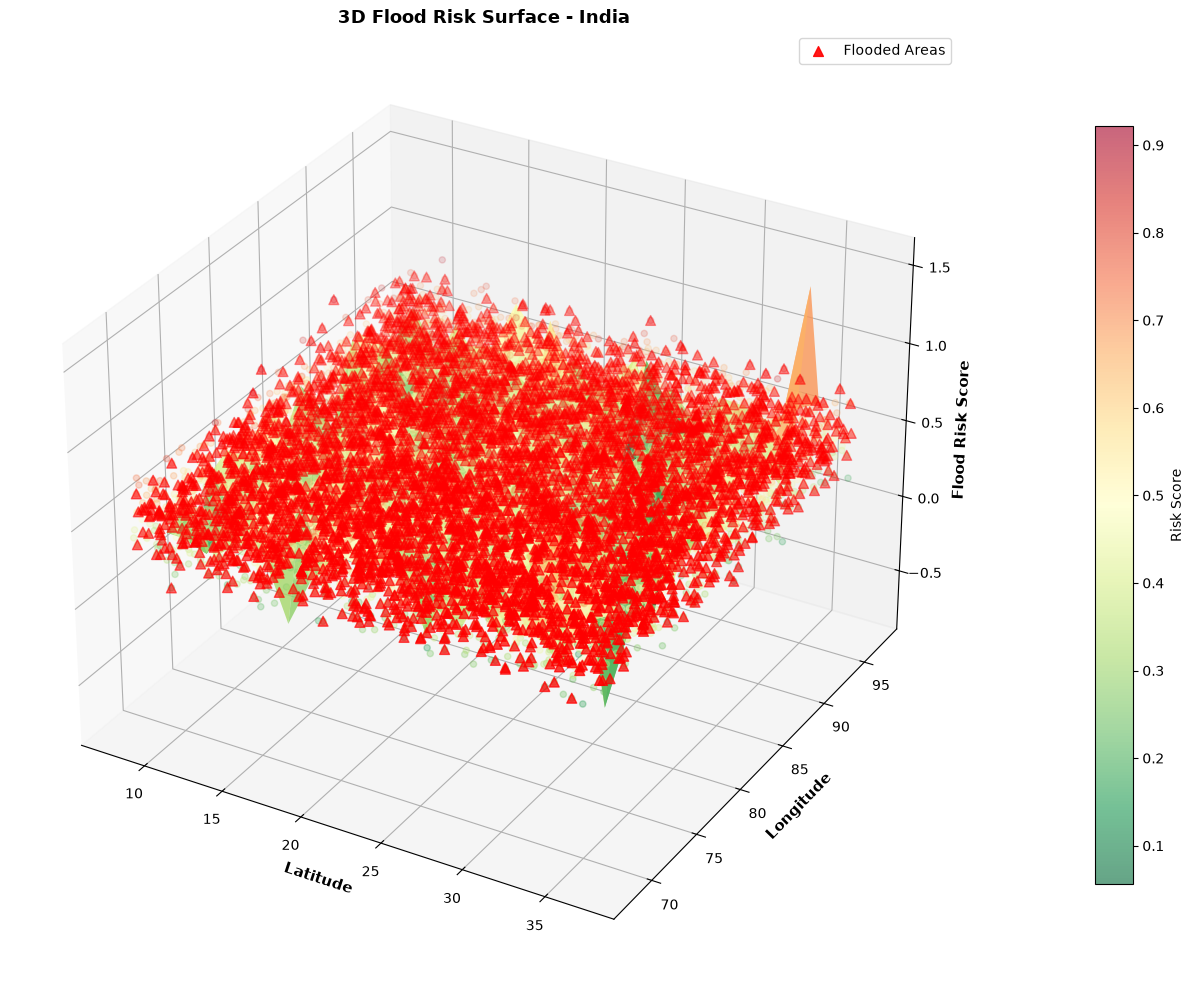


✓ Generating 3D Evacuation Network...


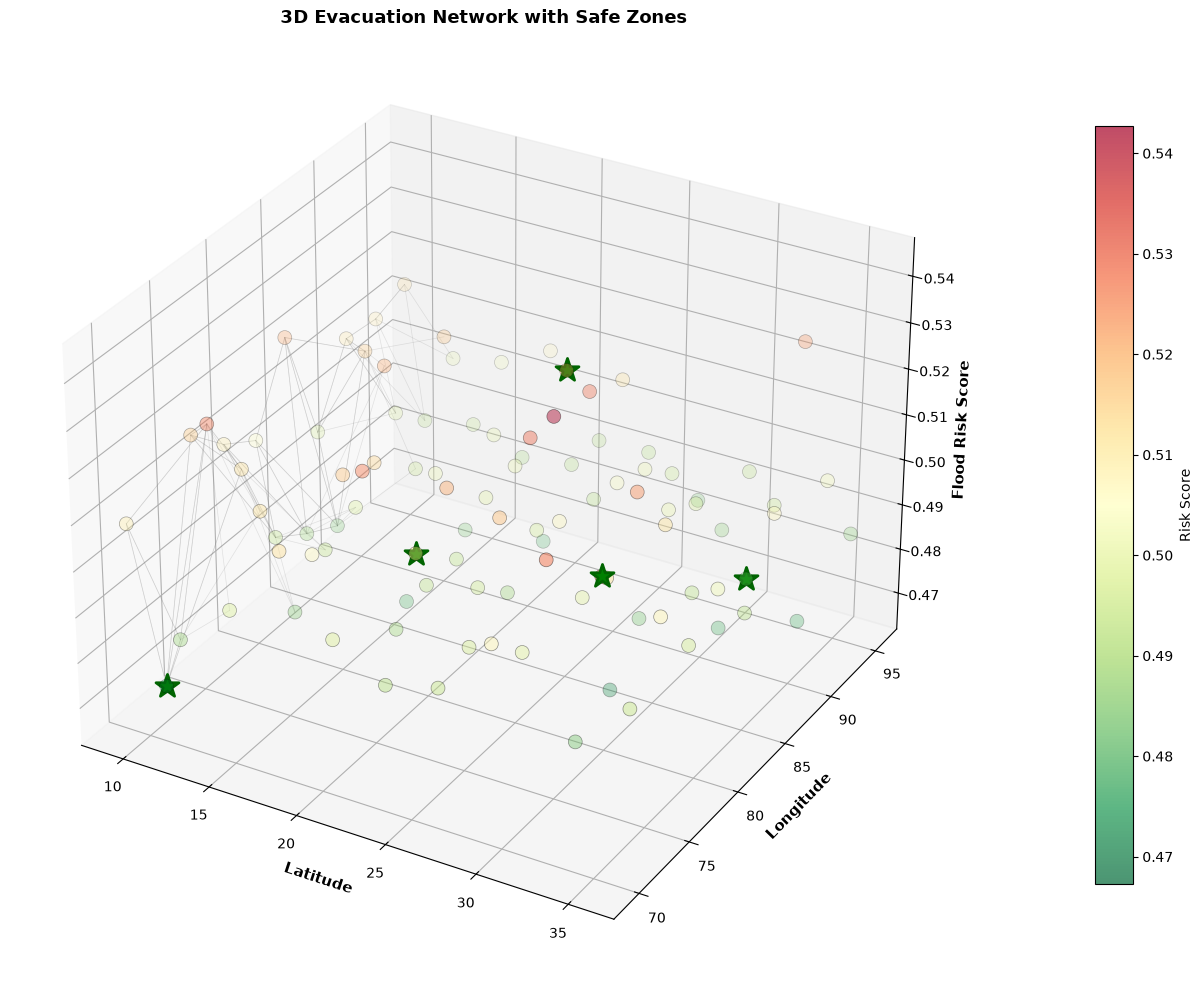


✓ Generating Evacuation Timeline...


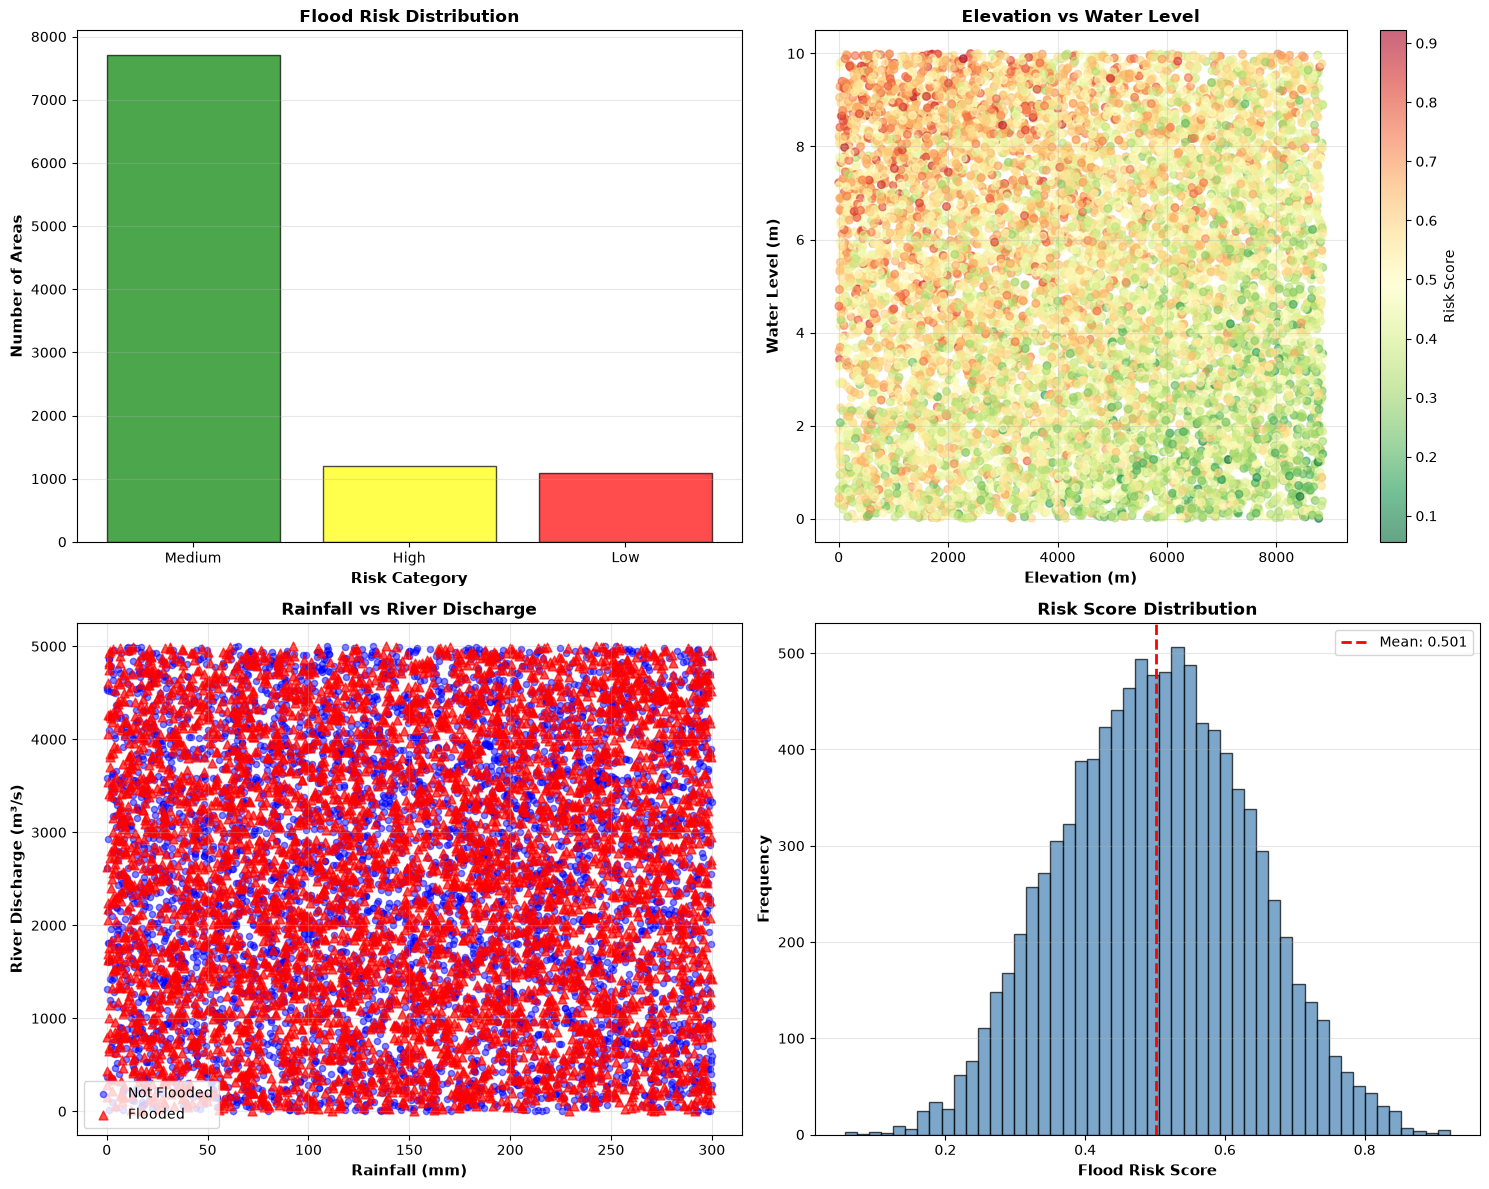


✓ Generating 3D Optimal Evacuation Route...


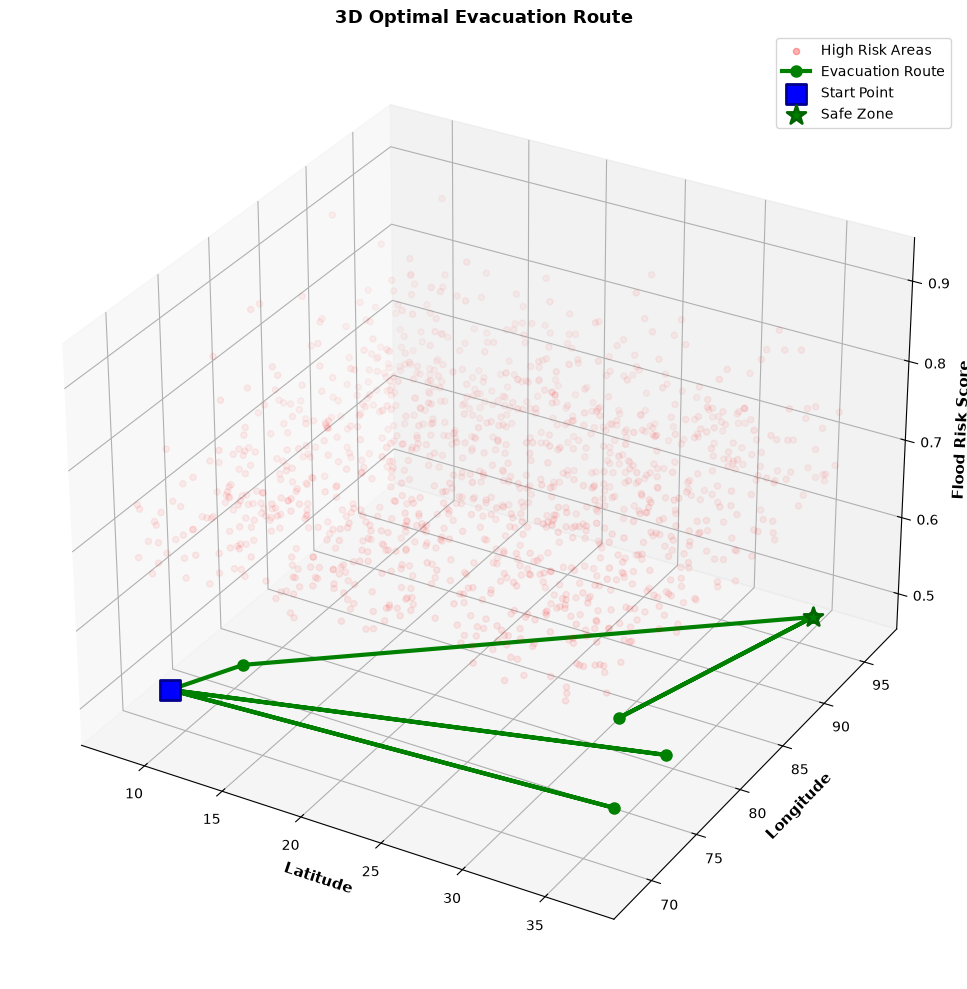


EXECUTION COMPLETED

✓ All visualizations saved to outputs folder
✓ Ready for evacuation planning and disaster management


In [25]:
# Declare global variables to be accessible outside main
global fitness_history_for_plotting
global pso_optimizer
global spatial_network

def main():
    """Main execution function"""
    global fitness_history_for_plotting # Declare global variable
    global pso_optimizer # Declare pso_optimizer as global
    global spatial_network # Declare spatial_network as global

    print("\n")
    print("█" * 80)
    print("█" + " " * 78 + "█")
    print("█" + " ADVANCED PSO EVACUATION MODEL WITH 3D VISUALIZATION ".center(78) + "█")
    print("█" + " Flood Risk Assessment for India ".center(78) + "█")
    print("█" * 80)

    # Create the output directory if it doesn't exist
    os.makedirs('/mnt/user-data/outputs/', exist_ok=True)

    # 1. Load and process data
    print("\n[STEP 1] Loading and Processing Data...")
    # Updated csv_path to the correct file path
    data_processor = FloodDataProcessor('flood_risk_dataset_india.csv')
    df = data_processor.df

    # 2. Build spatial network
    print("\n[STEP 2] Building Spatial Network...")
    spatial_network = SpatialNetwork(df, grid_size=10)

    # 3. Initialize and run PSO
    print("\n[STEP 3] Initializing PSO Evacuation Optimizer...")
    pso_optimizer = PSO_EvacuationOptimizer(
        network=spatial_network,
        safe_zones=5,
        population_to_evacuate=10000
    )

    print("\n[STEP 4] Running PSO Optimization...")
    fitness_history_for_plotting = pso_optimizer.optimize(iterations=200, w=0.8, c1=1.8, c2=1.8) # Assign to global variable

    # 4. Get results
    print("\n[STEP 5] Extracting Optimal Route...")
    optimal_route = pso_optimizer.get_optimal_route()

    print("\n" + "=" * 80)
    print("EVACUATION ROUTE ANALYSIS")
    print("=" * 80)
    print(f"\nRoute Length: {len(optimal_route['route'])} nodes")
    print(f"Total Distance: {optimal_route['distance']:.2f} grid units")
    print(f"Total Risk Exposure: {optimal_route['risk']:.4f}")
    print(f"Route Fitness Score: {optimal_route['fitness']:.4f}")

    # Evacuation timeline calculation
    total_time = optimal_route['distance'] * 10  # minutes per grid unit
    evacuees_per_hour = 100
    total_evacuation_time = (10000 / evacuees_per_hour)

    print(f"\n✓ Estimated Travel Time: {total_time:.1f} minutes")
    print(f"✓ Total Evacuation Duration: {total_evacuation_time:.1f} hours")
    print(f"✓ Evacuation Capacity: {evacuees_per_hour} people/hour")

    # 5. Create visualizations
    print("\n[STEP 6] Creating 3D Visualizations...")
    visualizer = Visualization3D(df, spatial_network, pso_optimizer)

    # Save visualizations
    visualizer.plot_3d_flood_risk_surface(
        save_path='/mnt/user-data/outputs/01_3D_Flood_Risk_Surface.png'
    )

    visualizer.plot_3d_evacuation_network(
        save_path='/mnt/user-data/outputs/02_3D_Evacuation_Network.png'
    )

    visualizer.plot_evacuation_timeline(
        save_path='/mnt/user-data/outputs/03_Evacuation_Analysis.png'
    )

    visualizer.plot_3d_optimal_route(
        save_path='/mnt/user-data/outputs/04_3D_Optimal_Route.png'
    )

    print("\n" + "=" * 80)
    print("EXECUTION COMPLETED")
    print("=" * 80)
    print("\n✓ All visualizations saved to outputs folder")
    print("✓ Ready for evacuation planning and disaster management")


if __name__ == "__main__":
    main()

## OPTIMAL EVACUATION ROUTE COORDINATES AND RISK SCORES

In [39]:
if 'pso_optimizer' in globals() and 'spatial_network' in globals():
    optimal_route_details = pso_optimizer.get_optimal_route()
    route_node_ids = optimal_route_details['route']

    print("\n--- Optimal Evacuation Route Coordinates and Risk Scores ---")
    print(f"Total Route Length: {len(route_node_ids)} nodes")
    print(f"Route Fitness Score: {optimal_route_details['fitness']:.4f}\n")

    route_data = []
    for i, node_id in enumerate(route_node_ids):
        node_info = spatial_network.nodes.get(node_id)
        if node_info:
            route_data.append({
                'Step': i,
                'Node ID': node_id,
                'Latitude': node_info['lat'],
                'Longitude': node_info['lon'],
                'Risk Score': node_info['risk_score'],
                'Elevation (m)': node_info['elevation']
            })
        else:
            route_data.append({
                'Step': i,
                'Node ID': node_id,
                'Latitude': 'N/A',
                'Longitude': 'N/A',
                'Risk Score': 'N/A',
                'Elevation (m)': 'N/A'
            })

    route_df = pd.DataFrame(route_data)
    print(route_df.to_markdown(index=False))

    print("\nFirst Node (Start Point):")
    print(f"  Latitude: {route_df.iloc[0]['Latitude']:.4f}, Longitude: {route_df.iloc[0]['Longitude']:.4f}, Risk: {route_df.iloc[0]['Risk Score']:.4f}")
    print("Last Node (Safe Zone / End Point):")
    print(f"  Latitude: {route_df.iloc[-1]['Latitude']:.4f}, Longitude: {route_df.iloc[-1]['Longitude']:.4f}, Risk: {route_df.iloc[-1]['Risk Score']:.4f}")

else:
    print("PSO optimizer or spatial network objects are not available. Please ensure the main function has been run successfully.")


--- Optimal Evacuation Route Coordinates and Risk Scores ---
Total Route Length: 9 nodes
Route Fitness Score: 2949.2651

|   Step |   Node ID |   Latitude |   Longitude |   Risk Score |   Elevation (m) |
|-------:|----------:|-----------:|------------:|-------------:|----------------:|
|      0 |         0 |    9.44991 |     69.4542 |     0.508872 |         4648.73 |
|      1 |        93 |   35.5422  |     78.1522 |     0.495485 |         4292.97 |
|      2 |         0 |    9.44991 |     69.4542 |     0.508872 |         4648.73 |
|      3 |        91 |   35.5422  |     72.3536 |     0.494011 |         4477.94 |
|      4 |         0 |    9.44991 |     69.4542 |     0.508872 |         4648.73 |
|      5 |        11 |   12.3491  |     72.3536 |     0.527809 |         4408.84 |
|      6 |        99 |   35.5422  |     95.5482 |     0.485036 |         4152.73 |
|      7 |        83 |   32.6431  |     78.1522 |     0.524727 |         4663.19 |
|      8 |        99 |   35.5422  |     95.5482 

## FLOOD EVACUATION ON THE MAP

In [48]:
import plotly.express as px

if 'route_df' in globals():
    # Ensure Latitude and Longitude are numeric
    route_df['Latitude'] = pd.to_numeric(route_df['Latitude'])
    route_df['Longitude'] = pd.to_numeric(route_df['Longitude'])

    # Create the scatter mapbox plot for nodes
    fig = px.scatter_mapbox(
        route_df,
        lat='Latitude',
        lon='Longitude',
        zoom=5,
        mapbox_style="open-street-map",
        color='Risk Score', # Color nodes by risk score
        size='Elevation (m)', # Size markers by elevation
        hover_name='Node ID',
        hover_data={
            'Latitude': ':.4f',
            'Longitude': ':.4f',
            'Risk Score': ':.4f',
            'Elevation (m)': ':.1f',
            'Step': True
        },
        title='Optimal Evacuation Route on Map'
    )

    # Add lines for the route path
    fig.add_trace(px.line_mapbox(
        route_df,
        lat='Latitude',
        lon='Longitude'
    ).update_traces(line=dict(color='green', width=3), name='Evacuation Route').data[0])

    # Mark the start point
    fig.add_trace(px.scatter_mapbox(
        route_df.iloc[[0]], # Select the first row for start point
        lat='Latitude',
        lon='Longitude',
        mapbox_style="open-street-map",
        color_discrete_sequence=['blue'],
        zoom=5,
        custom_data=['Node ID'],
        hover_name='Node ID',
        hover_data={'Latitude': ':.4f', 'Longitude': ':.4f', 'Risk Score': ':.4f', 'Elevation (m)': ':.1f'},
    ).update_traces(marker=dict(size=15, symbol='square'), name='Start Point').data[0]) # Removed line=dict(...)

    # Mark the end point (safe zone)
    fig.add_trace(px.scatter_mapbox(
        route_df.iloc[[-1]], # Select the last row for end point
        lat='Latitude',
        lon='Longitude',
        mapbox_style="open-street-map",
        color_discrete_sequence=['lime'],
        zoom=5,
        custom_data=['Node ID'],
        hover_name='Node ID',
        hover_data={'Latitude': ':.4f', 'Longitude': ':.4f', 'Risk Score': ':.4f', 'Elevation (m)': ':.1f'},
    ).update_traces(marker=dict(size=15, symbol='star'), name='End Point (Safe Zone').data[0]) # Removed line=dict(...)


    fig.update_layout(
        legend_title_text='Legend',
        margin={"r":0,"t":50,"l":0,"b":0}
    )
    fig.show()
else:
    print("Route data (route_df) not found. Please ensure the previous cells have been executed successfully.")


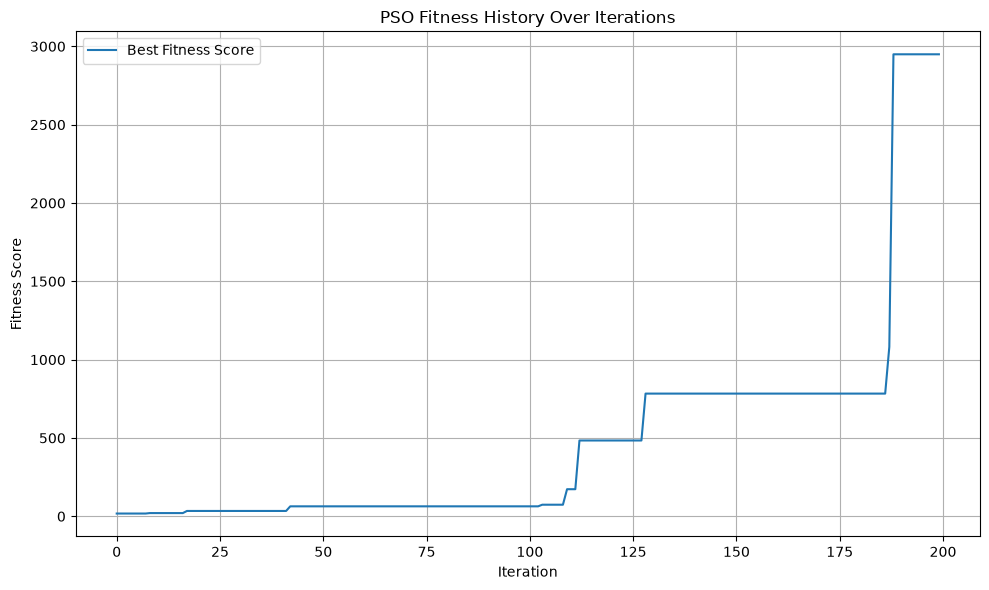

In [41]:
import matplotlib.pyplot as plt

# fitness_history_for_plotting is now a global variable populated by the main function

fig = plt.figure(figsize=(10, 6))
plt.plot(fitness_history_for_plotting, label='Best Fitness Score')
plt.xlabel('Iteration')
plt.ylabel('Fitness Score')
plt.title('PSO Fitness History Over Iterations')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
!pip install plotly